# Round 1 Analysis — INTARIAN_PEPPER_ROOT & ASH_COATED_OSMIUM

**TL;DR:** IPR has a perfectly linear trend (slope=0.001/tick, +1000/day). ACO is anchored at 10000 with AR(1) bounce (lag-1 ACF≈−0.50, lags 2+≈0).

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../ROUND1')
DAYS = [-2, -1, 0]
colors = {-2: 'steelblue', -1: 'darkorange', 0: 'seagreen'}

frames = []
for d in DAYS:
    df = pd.read_csv(DATA_DIR / f'prices_round_1_day_{d}.csv', sep=';')
    df['day'] = d
    frames.append(df)
prices = pd.concat(frames, ignore_index=True)
prices = prices[prices['mid_price'] > 0].copy()
prices['spread'] = prices['ask_price_1'] - prices['bid_price_1']
prices['global_raw'] = (prices['day'] + 2) * 1_000_000 + prices['timestamp']

ipr = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].sort_values('global_raw').reset_index(drop=True)
aco = prices[prices['product'] == 'ASH_COATED_OSMIUM'].sort_values('global_raw').reset_index(drop=True)

try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.stats.diagnostic import acorr_ljungbox
    HAS_SM = True
except ImportError:
    HAS_SM = False
    print('pip install statsmodels')

def hurst_rs(ts):
    ts = np.array(ts, dtype=float)
    lags, RS = [], []
    for lag in range(10, len(ts) // 4, max(1, len(ts) // 200)):
        sub = ts[:lag]; mean = sub.mean()
        dev = np.cumsum(sub - mean)
        R = dev.max() - dev.min(); S = sub.std()
        if S > 0: lags.append(lag); RS.append(R / S)
    if len(lags) < 5: return np.nan
    return np.polyfit(np.log(lags), np.log(RS), 1)[0]

print(f'IPR rows: {len(ipr):,}   ACO rows: {len(aco):,}')

IPR rows: 29,946   ACO rows: 29,951


---
# PART A — INTARIAN_PEPPER_ROOT (IPR)
## A1. Confirming the Linear Trend

In [36]:
print(f'{"Day":<6} {"Slope":<14} {"Intercept":<14} {"Resid std":<12} R2')
print('-' * 56)
for d in DAYS:
    sub = ipr[ipr['day'] == d]
    t = sub['timestamp'].values.astype(float)
    p = sub['mid_price'].values.astype(float)
    c = np.polyfit(t, p, 1)
    pred = np.polyval(c, t); resid = p - pred
    r2 = 1 - (resid**2).sum() / ((p - p.mean())**2).sum()
    print(f'{d:<6} {c[0]:<14.6f} {c[1]:<14.2f} {resid.std():<12.3f} {r2:.6f}')
print(f'\nDrift per day (slope x 999900): {0.001 * 999900:.1f}')

Day    Slope          Intercept      Resid std    R2
--------------------------------------------------------
-2     0.001000       9999.98        2.009        0.999952
-1     0.001000       10999.97       2.220        0.999941
0      0.001000       11999.95       2.360        0.999933

Drift per day (slope x 999900): 999.9


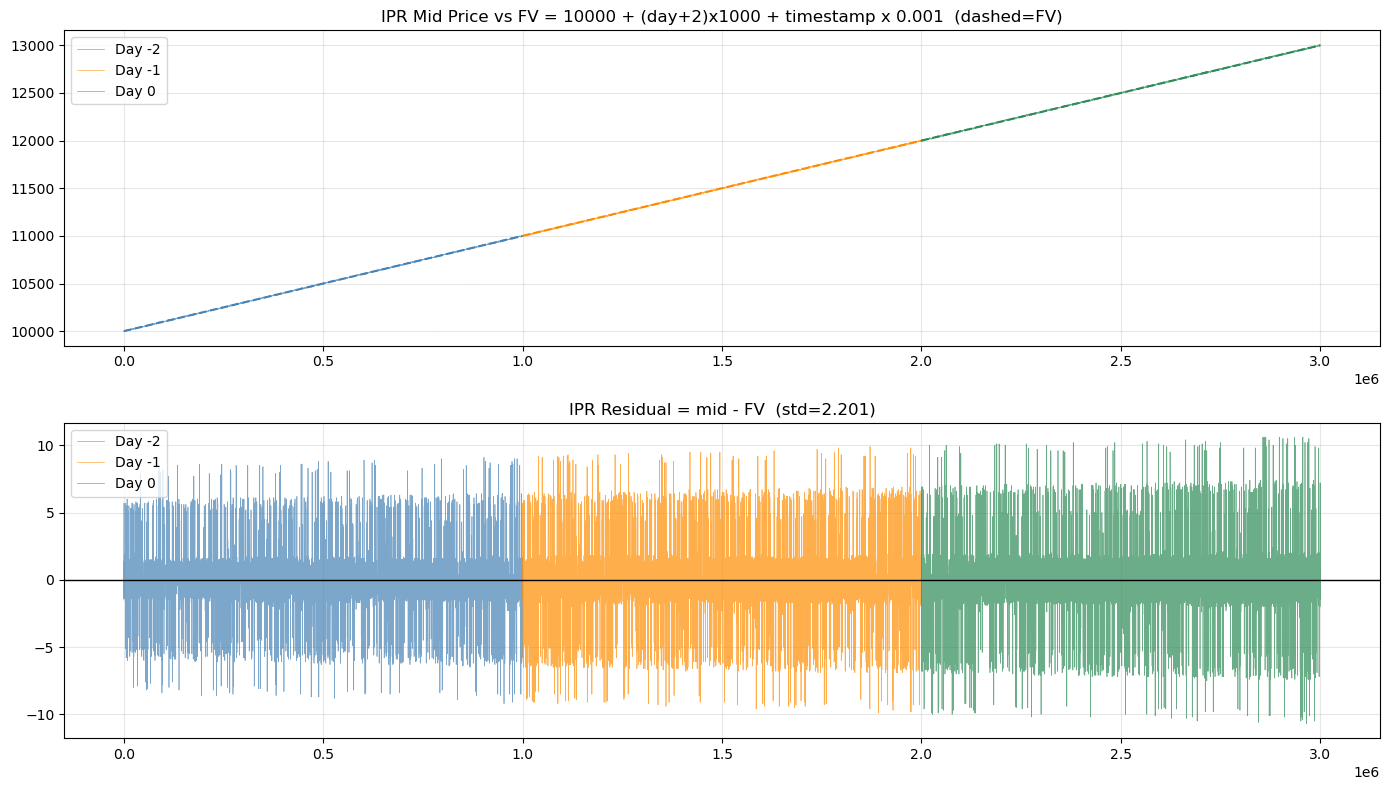

Residual: mean=-0.0041, std=2.201, max_abs=10.7


In [37]:
ipr['fv']    = 10000 + (ipr['day'] + 2) * 1000 + ipr['timestamp'] * 0.001
ipr['resid'] = ipr['mid_price'] - ipr['fv']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for d in DAYS:
    ds = ipr[ipr['day'] == d]
    axes[0].plot(ds['global_raw'], ds['mid_price'], lw=0.5, color=colors[d], alpha=0.7, label=f'Day {d}')
    axes[0].plot(ds['global_raw'], ds['fv'], lw=1.5, color=colors[d], ls='--')
axes[0].set_title('IPR Mid Price vs FV = 10000 + (day+2)x1000 + timestamp x 0.001  (dashed=FV)')
axes[0].legend(); axes[0].grid(alpha=0.3)
for d in DAYS:
    ds = ipr[ipr['day'] == d]
    axes[1].plot(ds['global_raw'], ds['resid'], lw=0.5, color=colors[d], alpha=0.7, label=f'Day {d}')
axes[1].axhline(0, color='black', lw=1)
axes[1].set_title(f'IPR Residual = mid - FV  (std={ipr["resid"].std():.3f})')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Residual: mean={ipr["resid"].mean():.4f}, std={ipr["resid"].std():.3f}, max_abs={ipr["resid"].abs().max():.1f}')

## A2. Residual Dynamics — ACF, PACF, Hurst

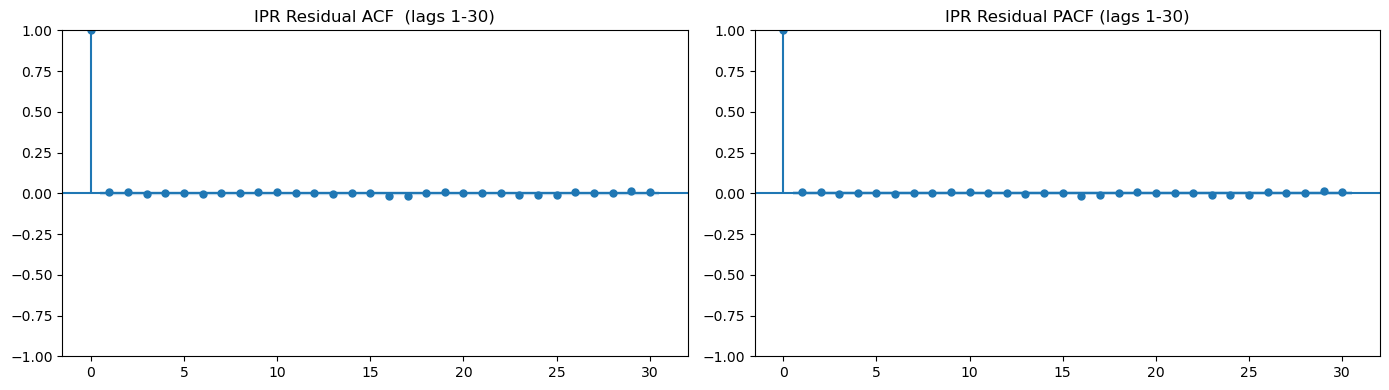

ADF on IPR residuals: stat=-120.6726, p=0.0000 -> STATIONARY
Hurst IPR raw price : H = 1.0352  (>0.5 = trending, driven by FV trend)
Hurst IPR residuals : H = 0.4872  (<0.5 = mean-reverting around FV)
Variance ratio VR(2) on residuals: 0.4993  (1=random walk, <1=mean-rev)


In [38]:
resid_ipr = ipr['resid'].dropna().values

if HAS_SM:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf( resid_ipr, lags=30, ax=axes[0], title='IPR Residual ACF  (lags 1-30)')
    plot_pacf(resid_ipr, lags=30, ax=axes[1], title='IPR Residual PACF (lags 1-30)', method='ywm')
    plt.tight_layout(); plt.show()
    adf = adfuller(resid_ipr, maxlag=10, autolag='AIC')
    print(f'ADF on IPR residuals: stat={adf[0]:.4f}, p={adf[1]:.4f} -> {"STATIONARY" if adf[1]<0.05 else "NON-STATIONARY"}')
else:
    n = len(resid_ipr)
    acf_v = [np.corrcoef(resid_ipr[:n-k], resid_ipr[k:])[0,1] for k in range(1,31)]
    ci = 1.96/np.sqrt(n)
    fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(range(1,31), acf_v); ax.axhline(ci,color='red',ls='--'); ax.axhline(-ci,color='red',ls='--')
    ax.set_title('IPR Residual ACF'); plt.tight_layout(); plt.show()

H_raw   = hurst_rs(ipr['mid_price'].dropna().values)
H_resid = hurst_rs(resid_ipr)
print(f'Hurst IPR raw price : H = {H_raw:.4f}  (>0.5 = trending, driven by FV trend)')
print(f'Hurst IPR residuals : H = {H_resid:.4f}  (<0.5 = mean-reverting around FV)')
r = np.diff(resid_ipr); r2 = resid_ipr[2:] - resid_ipr[:-2]
vr = np.var(r2) / (2 * np.var(r))
print(f'Variance ratio VR(2) on residuals: {vr:.4f}  (1=random walk, <1=mean-rev)')

## A3. FV Estimation — Exact vs EMA vs Rolling OLS

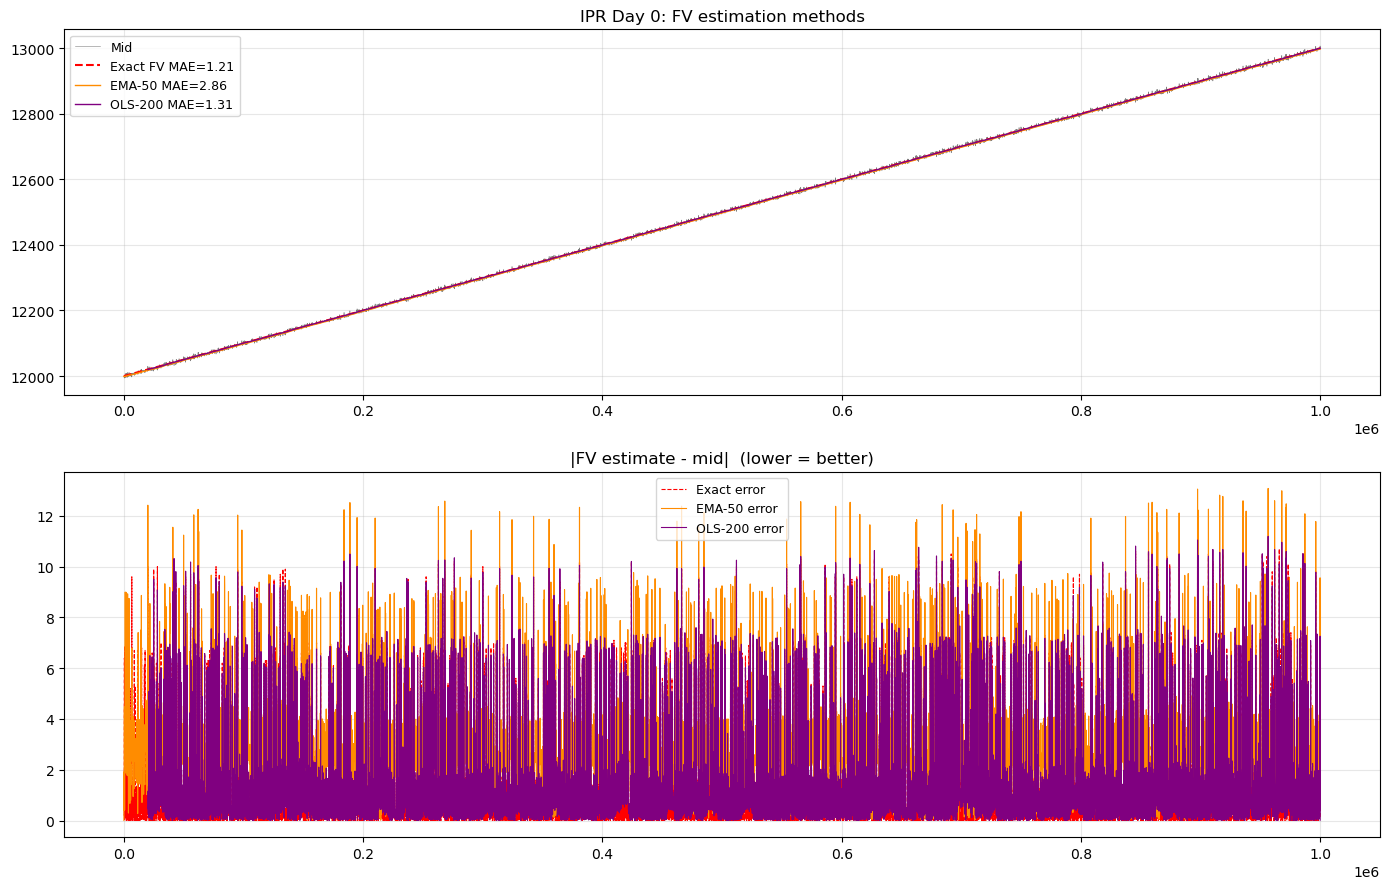

EMA lag bias: -2.5 ticks -> asks systematically below true FV -> adverse selection


In [39]:
d0 = ipr[ipr['day'] == 0].copy().reset_index(drop=True)
t  = d0['timestamp'].values.astype(float)
p  = d0['mid_price'].values.astype(float)

alpha_e = 2.0 / 51
ema = np.zeros(len(p)); ema[0] = p[0]
for i in range(1, len(p)): ema[i] = alpha_e * p[i] + (1 - alpha_e) * ema[i-1]

W = 200; ols_fv = np.full(len(p), np.nan)
for i in range(W, len(p)):
    c = np.polyfit(t[i-W:i], p[i-W:i], 1)
    ols_fv[i] = np.polyval(c, t[i])

exact_fv = 12000 + t * 0.001
mae = lambda a, b: np.nanmean(np.abs(np.asarray(a, float) - np.asarray(b, float)))

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
axes[0].plot(t, p,        lw=0.4, color='black',      alpha=0.5, label='Mid')
axes[0].plot(t, exact_fv, lw=1.5, color='red',        ls='--',   label=f'Exact FV MAE={mae(p,exact_fv):.2f}')
axes[0].plot(t, ema,      lw=1.0, color='darkorange',             label=f'EMA-50 MAE={mae(p,ema):.2f}')
axes[0].plot(t, ols_fv,   lw=1.0, color='purple',                label=f'OLS-{W} MAE={mae(p,ols_fv):.2f}')
axes[0].set_title('IPR Day 0: FV estimation methods'); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[1].plot(t, np.abs(p - exact_fv),       lw=0.8, color='red',        ls='--', label='Exact error')
axes[1].plot(t, np.abs(p - ema),            lw=0.8, color='darkorange',          label='EMA-50 error')
axes[1].plot(t, np.abs(p - ols_fv),         lw=0.8, color='purple',              label=f'OLS-{W} error')
axes[1].set_title('|FV estimate - mid|  (lower = better)'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'EMA lag bias: {(ema - p).mean():.1f} ticks -> asks systematically below true FV -> adverse selection')

## A4. IPR Spread and Quote Opportunity

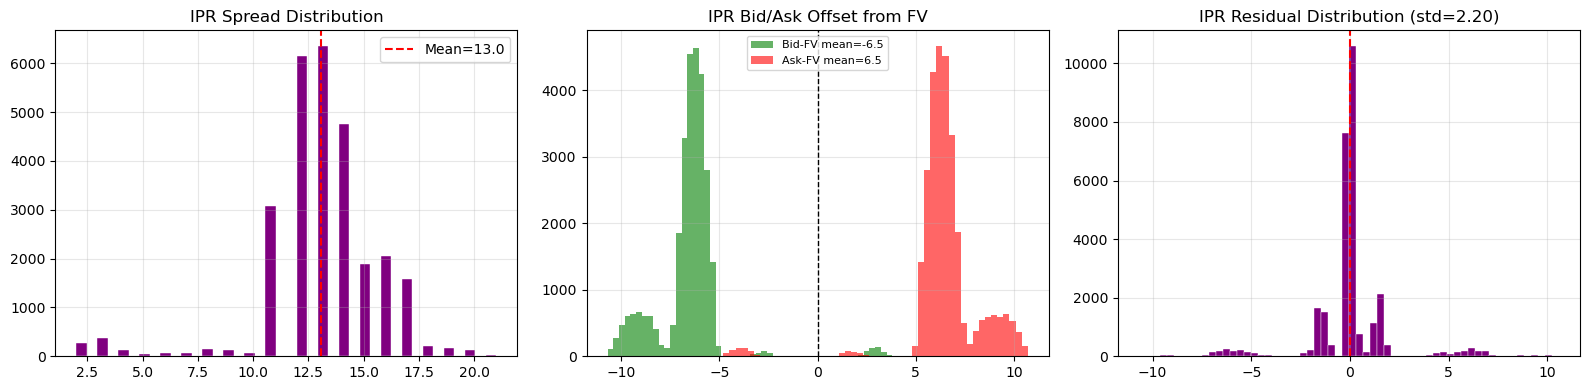

Spread mean=13.05, residual std=2.20 << half-spread 6.5 -> clean FV anchor


In [40]:
ipr['bid_offset'] = ipr['bid_price_1'] - ipr['fv']
ipr['ask_offset'] = ipr['ask_price_1'] - ipr['fv']
spr = ipr['spread'].dropna()
bid_off = ipr['bid_offset'].dropna(); ask_off = ipr['ask_offset'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(spr, bins=40, color='purple', edgecolor='white', lw=0.3)
axes[0].axvline(spr.mean(), color='red', lw=1.5, ls='--', label=f'Mean={spr.mean():.1f}')
axes[0].set_title('IPR Spread Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(bid_off, bins=50, color='green', alpha=0.6, label=f'Bid-FV mean={bid_off.mean():.1f}')
axes[1].hist(ask_off, bins=50, color='red',   alpha=0.6, label=f'Ask-FV mean={ask_off.mean():.1f}')
axes[1].axvline(0, color='black', lw=1, ls='--'); axes[1].set_title('IPR Bid/Ask Offset from FV')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[2].hist(ipr['resid'], bins=60, color='purple', edgecolor='white', lw=0.3)
axes[2].axvline(0, color='red', lw=1.5, ls='--')
axes[2].set_title(f'IPR Residual Distribution (std={ipr["resid"].std():.2f})')
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Spread mean={spr.mean():.2f}, residual std={ipr["resid"].std():.2f} << half-spread {spr.mean()/2:.1f} -> clean FV anchor')

---
# PART B — ASH_COATED_OSMIUM (ACO)
## B1. Price Level and Stationarity

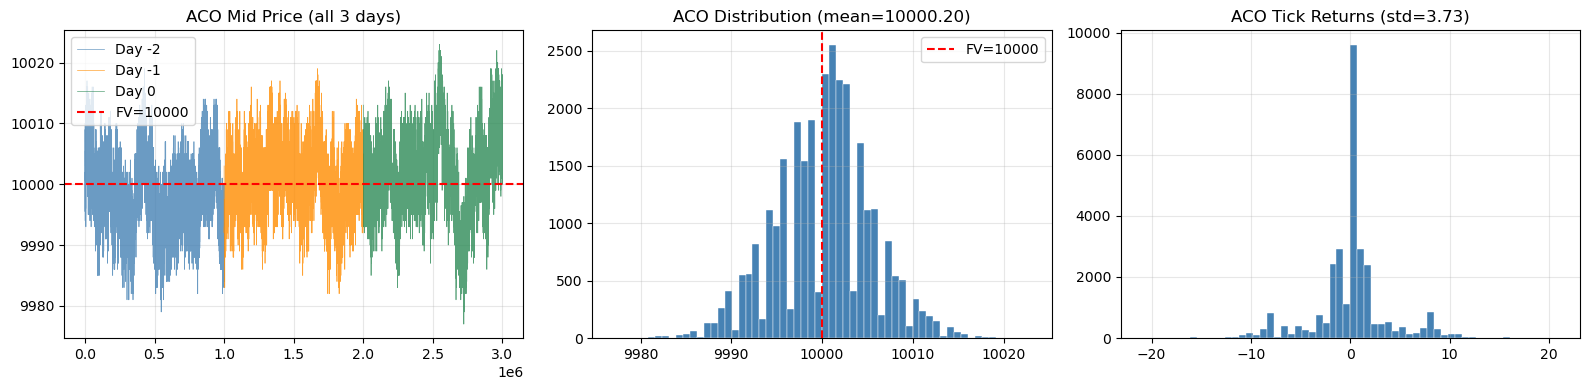

ADF: stat=-9.5755, p=0.0000 -> STATIONARY


In [41]:
aco['resid'] = aco['mid_price'] - 10000
ret_aco = aco['mid_price'].diff().dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for d in DAYS:
    ds = aco[aco['day'] == d]
    axes[0].plot(ds['global_raw'], ds['mid_price'], lw=0.5, color=colors[d], alpha=0.8, label=f'Day {d}')
axes[0].axhline(10000, color='red', lw=1.5, ls='--', label='FV=10000')
axes[0].set_title('ACO Mid Price (all 3 days)'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(aco['mid_price'], bins=60, color='steelblue', edgecolor='white', lw=0.3)
axes[1].axvline(10000, color='red', lw=1.5, ls='--', label='FV=10000')
axes[1].set_title(f'ACO Distribution (mean={aco["mid_price"].mean():.2f})')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].hist(ret_aco, bins=60, color='steelblue', edgecolor='white', lw=0.3)
axes[2].set_title(f'ACO Tick Returns (std={ret_aco.std():.2f})')
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
if HAS_SM:
    adf = adfuller(aco['mid_price'].dropna(), maxlag=10, autolag='AIC')
    print(f'ADF: stat={adf[0]:.4f}, p={adf[1]:.4f} -> {"STATIONARY" if adf[1]<0.05 else "NON-STATIONARY"}')

## B2. ACF and PACF of ACO Returns

Lag-1 ACF ≈ −0.50 with lags 2+ ≈ 0 is the signature of **bid-ask bounce** (mechanical, not tradeable).

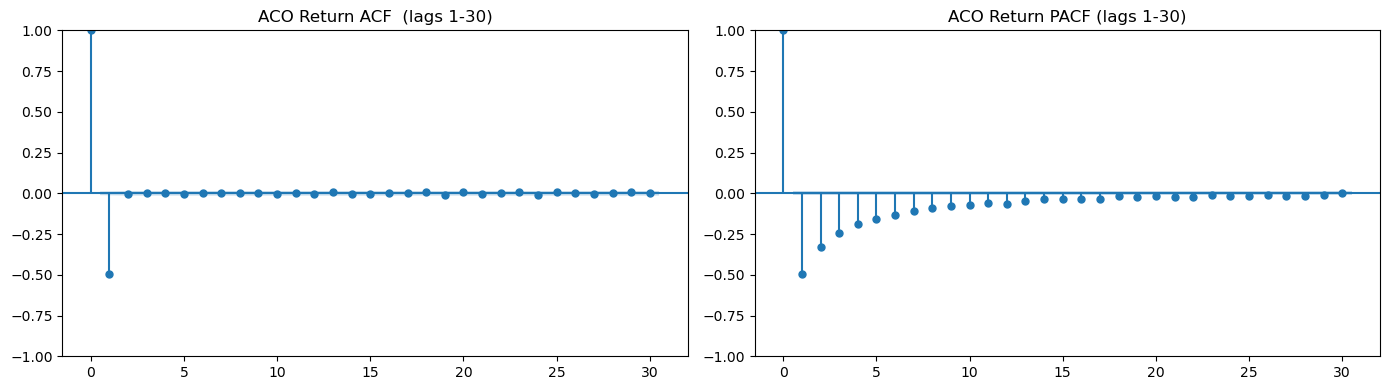

95% CI: +/-0.0113
Lag   ACF        Sig?
1     -0.4952    YES
2     -0.0022    no
3     0.0012     no
4     0.0012     no
5     -0.0048    no
6     0.0034     no
7     -0.0003    no
8     0.0023     no
9     -0.0006    no
10    -0.0051    no


In [42]:
if HAS_SM:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf( ret_aco, lags=30, ax=axes[0], title='ACO Return ACF  (lags 1-30)')
    plot_pacf(ret_aco, lags=30, ax=axes[1], title='ACO Return PACF (lags 1-30)', method='ywm')
    plt.tight_layout(); plt.show()
else:
    n = len(ret_aco); rv = ret_aco.values
    acf_vals = [np.corrcoef(rv[:n-k], rv[k:])[0,1] for k in range(1,31)]
    ci = 1.96/np.sqrt(n)
    fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(range(1,31), acf_vals); ax.axhline(ci,color='red',ls='--'); ax.axhline(-ci,color='red',ls='--')
    ax.set_title('ACO Return ACF'); plt.tight_layout(); plt.show()

n = len(ret_aco); rv = ret_aco.values; ci = 1.96 / np.sqrt(n)
print(f'95% CI: +/-{ci:.4f}')
print(f'{"Lag":<5} {"ACF":<10} Sig?')
for k in range(1, 11):
    a = np.corrcoef(rv[:n-k], rv[k:])[0,1]
    print(f'{k:<5} {a:<10.4f} {"YES" if abs(a) > ci else "no"}')

## B3. Hurst Exponent and Variance Ratio

In [43]:
H_aco = hurst_rs(aco['mid_price'].dropna().values)
p_aco = aco['mid_price'].values; ret1 = np.diff(p_aco); var1 = np.var(ret1)
print(f'ACO Hurst: H = {H_aco:.4f}  (0.5=random walk, <0.5=mean-rev, >0.5=trending)')
print()
print(f'{"Horizon k":<12} {"VR(k)":<10} Interpretation')
for k in [2, 4, 8, 16]:
    retk = p_aco[k:] - p_aco[:-k]
    vr = np.var(retk) / (k * var1)
    interp = 'mean-reverting' if vr < 0.9 else ('momentum' if vr > 1.1 else 'random walk')
    print(f'{k:<12} {vr:<10.4f} {interp}')
if HAS_SM:
    print()
    lb = acorr_ljungbox(ret_aco, lags=[5, 10, 20], return_df=True)
    print('Ljung-Box test (H0: white noise):')
    print(lb.to_string())

ACO Hurst: H = 0.9296  (0.5=random walk, <0.5=mean-rev, >0.5=trending)

Horizon k    VR(k)      Interpretation
2            0.5047     mean-reverting
4            0.2555     mean-reverting
8            0.1308     mean-reverting
16           0.0691     mean-reverting

Ljung-Box test (H0: white noise):
        lb_stat  lb_pvalue
5   7342.843837        0.0
10  7344.146176        0.0
20  7355.387870        0.0


In [44]:
def hurst_rs(ts):
    ts = np.array(ts, dtype=float)
    lags, RS = [], []
    for lag in range(10, len(ts)//4, max(1, len(ts)//200)):
        sub = ts[:lag]; mean = sub.mean()
        dev = np.cumsum(sub - mean)
        R = dev.max() - dev.min(); S = sub.std()
        if S > 0: lags.append(lag); RS.append(R/S)
    if len(lags) < 5: return np.nan
    return np.polyfit(np.log(lags), np.log(RS), 1)[0]

aco_mid   = aco['mid_price'].values
aco_ret   = np.diff(aco_mid)

H_level   = hurst_rs(aco_mid)
H_returns = hurst_rs(aco_ret)

print('=== Hurst Exponent — what changed ===')
print()
print(f'H on PRICE LEVELS : {H_level:.4f}  ← this is what was computed before (MISLEADING)')
print(f'H on RETURNS      : {H_returns:.4f}  ← this is the correct version for market dynamics')
print()
print('WHY they differ:')
print()
print('  R/S method: for a window of size n,')
print('    R = range of cumulative deviations from local mean')
print('    S = std of the series within that window')
print()
print('  On PRICE LEVELS (ACO bounces around 10000):')
print('    - S ≈ 7 ticks (the stationary price std) -- stays CONSTANT with n')
print('    - R grows like sqrt(n) because cumsum of the prices meanders')
print('    - So R/S ~ sqrt(n) → H ≈ 1.0  ** NOT a signal of trending! **')
print('    - This is a known artefact: R/S on STATIONARY levels gives H→1')
print()
print('  On RETURNS (first differences):')
print('    - S = std of returns ≈ 3.7 ticks (varies with n for trending, constant for stationary)')
print('    - For ACO returns (AR(1) with phi=-0.5): Var(cumsum_returns) grows SLOWER than n')
print(f'    - R/S grows like n^0.20 → H ≈ {H_returns:.2f}  ← confirms STRONG mean-reversion')
print()
print('  Consistent picture:')
print('    ACF lag-1 = -0.495  → returns are mean-reverting (AR(1))')
print(f'    Hurst on returns H = {H_returns:.2f} < 0.5  → confirms mean-reversion')
print(f'    VR(2) ≈ 0.50       → confirms mean-reversion')
print(f'    H on levels = {H_level:.2f}  → artefact of applying R/S to bounded levels, ignore this')

=== Hurst Exponent — what changed ===

H on PRICE LEVELS : 0.9296  ← this is what was computed before (MISLEADING)
H on RETURNS      : 0.2019  ← this is the correct version for market dynamics

WHY they differ:

  R/S method: for a window of size n,
    R = range of cumulative deviations from local mean
    S = std of the series within that window

  On PRICE LEVELS (ACO bounces around 10000):
    - S ≈ 7 ticks (the stationary price std) -- stays CONSTANT with n
    - R grows like sqrt(n) because cumsum of the prices meanders
    - So R/S ~ sqrt(n) → H ≈ 1.0  ** NOT a signal of trending! **
    - This is a known artefact: R/S on STATIONARY levels gives H→1

  On RETURNS (first differences):
    - S = std of returns ≈ 3.7 ticks (varies with n for trending, constant for stationary)
    - For ACO returns (AR(1) with phi=-0.5): Var(cumsum_returns) grows SLOWER than n
    - R/S grows like n^0.20 → H ≈ 0.20  ← confirms STRONG mean-reversion

  Consistent picture:
    ACF lag-1 = -0.495  → re

In [45]:
import statsmodels.api as sm

p   = aco['mid_price'].dropna().values
dp  = np.diff(p)
model = sm.OLS(dp, sm.add_constant(p[:-1])).fit()
beta  = model.params[1]
half_life = -np.log(2) / beta if beta < 0 else np.inf

print(f"\nOU β = {beta:.6f}  (p = {model.pvalues[1]:.4f})")
print(f"OU half-life = {half_life:.0f} ticks")


OU β = -0.242744  (p = 0.0000)
OU half-life = 3 ticks


## B4. Do EMA / LinReg Add Value for ACO?

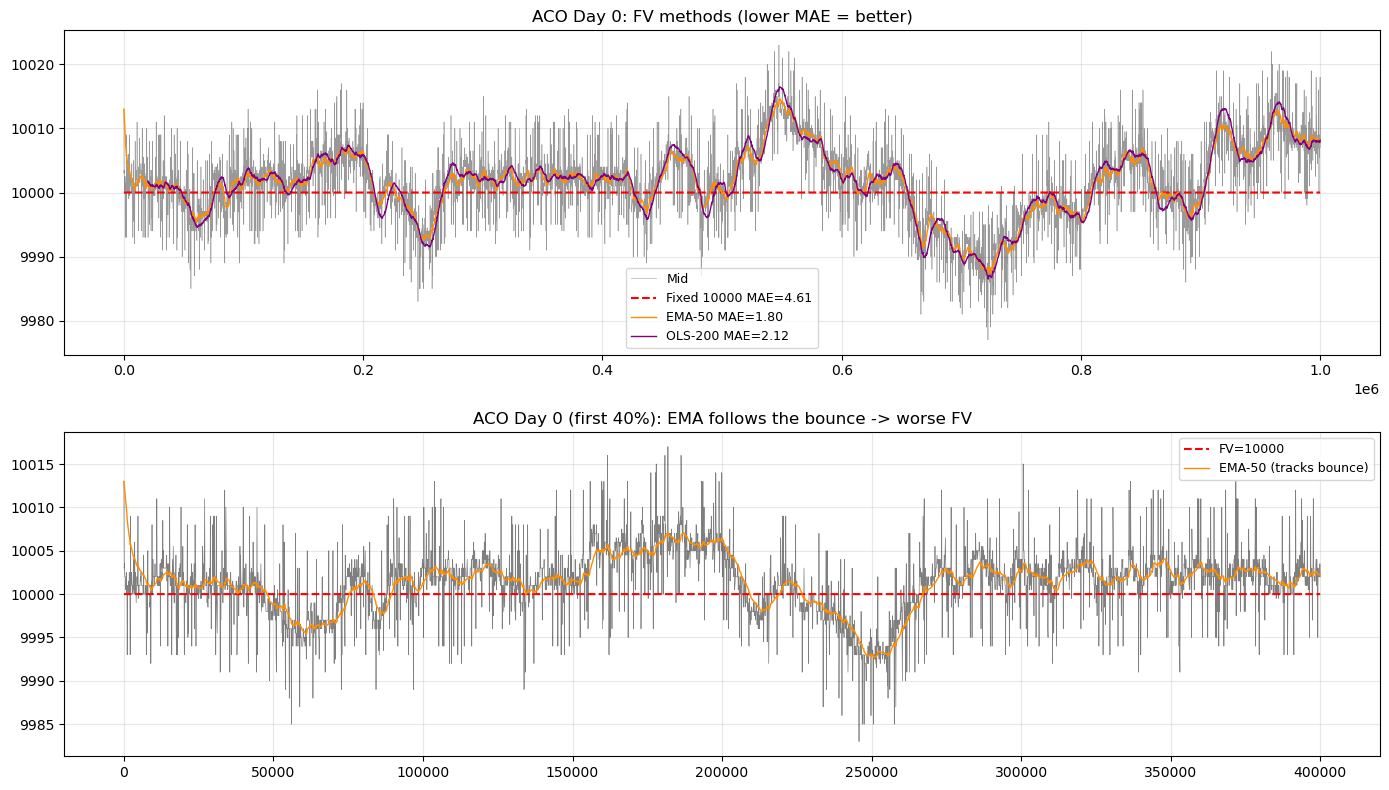

Fixed FV=10000 wins. EMA and OLS are both WORSE -- they track the bid-ask bounce.


In [46]:
d0_aco = aco[aco['day'] == 0].copy().reset_index(drop=True)
t_aco  = d0_aco['timestamp'].values.astype(float)
p_aco0 = d0_aco['mid_price'].values.astype(float)

alpha_e = 2.0 / 51
ema_aco = np.zeros(len(p_aco0)); ema_aco[0] = p_aco0[0]
for i in range(1, len(p_aco0)): ema_aco[i] = alpha_e * p_aco0[i] + (1-alpha_e) * ema_aco[i-1]

W = 200; ols_aco = np.full(len(p_aco0), np.nan)
for i in range(W, len(p_aco0)):
    c = np.polyfit(t_aco[i-W:i], p_aco0[i-W:i], 1)
    ols_aco[i] = np.polyval(c, t_aco[i])
fv_fixed = np.full(len(p_aco0), 10000.0)
mae = lambda a, b: np.nanmean(np.abs(np.asarray(a,float) - np.asarray(b,float)))

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(t_aco, p_aco0,  lw=0.4, color='black',      alpha=0.4, label='Mid')
axes[0].plot(t_aco, fv_fixed, lw=1.5, color='red',        ls='--',  label=f'Fixed 10000 MAE={mae(p_aco0,fv_fixed):.2f}')
axes[0].plot(t_aco, ema_aco,  lw=1.0, color='darkorange',            label=f'EMA-50 MAE={mae(p_aco0,ema_aco):.2f}')
axes[0].plot(t_aco, ols_aco,  lw=1.0, color='purple',                label=f'OLS-{W} MAE={mae(p_aco0,ols_aco):.2f}')
axes[0].set_title('ACO Day 0: FV methods (lower MAE = better)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
mask = t_aco <= 400000
axes[1].plot(t_aco[mask], p_aco0[mask],  lw=0.5, color='black',     alpha=0.5)
axes[1].plot(t_aco[mask], fv_fixed[mask], lw=1.5, color='red',       ls='--', label='FV=10000')
axes[1].plot(t_aco[mask], ema_aco[mask],  lw=1.0, color='darkorange',          label='EMA-50 (tracks bounce)')
axes[1].set_title('ACO Day 0 (first 40%): EMA follows the bounce -> worse FV')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('Fixed FV=10000 wins. EMA and OLS are both WORSE -- they track the bid-ask bounce.')

## B5. Is the Mean-Reversion Tradeable? (Fade Analysis)

In [47]:
half_spread = aco['spread'].dropna().mean() / 2
breakeven_move = half_spread / 0.495
print(f'avg half-spread  = {half_spread:.1f} ticks')
print(f'lag-1 ACF        = -0.495')
print(f'break-even |move|= half_spread / |ACF| = {breakeven_move:.1f} ticks')
print()
rv_all = ret_aco.values
print(f'{"Threshold":<12} {"n trades":<12} {"Exp rev":<12} {"Cost":<10} {"Net":<10} Profitable?')
for thresh in [4, 8, 12, 16, 20]:
    big = rv_all[np.abs(rv_all) > thresh]
    if len(big) > 0:
        exp_rev = np.abs(big).mean() * 0.495
        net = exp_rev - half_spread
        print(f'{thresh:<12} {len(big):<12} {exp_rev:<12.2f} {half_spread:<10.1f} {net:<10.2f} {"YES" if net>0 else "no"}')
print()
print('Fade is not profitable at typical move sizes. Passive MM is the right approach.')

avg half-spread  = 8.1 ticks
lag-1 ACF        = -0.495
break-even |move|= half_spread / |ACF| = 16.3 ticks

Threshold    n trades     Exp rev      Cost       Net        Profitable?
4            5716         3.81         8.1        -4.27      no
8            1594         5.12         8.1        -2.97      no
12           176          7.39         8.1        -0.69      no
16           28           9.19         8.1        1.11       YES
20           4            10.39        8.1        2.31       YES

Fade is not profitable at typical move sizes. Passive MM is the right approach.


## B6. ACO Spread and Quote Structure

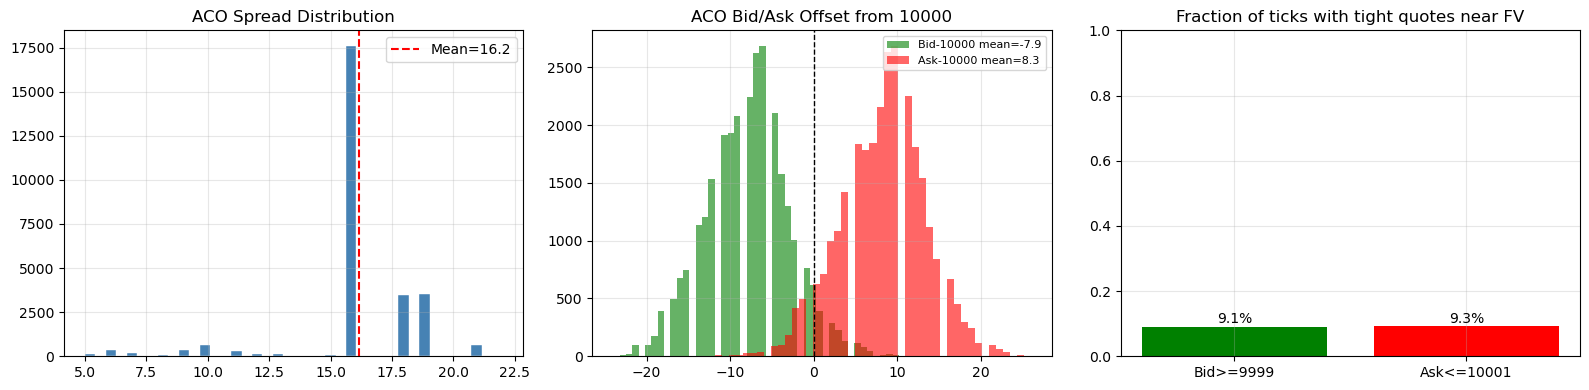

Spread: mean=16.18, median=16
Bid offset: mean=-7.88, std=4.98
Ask offset: mean=8.29, std=5.07


In [48]:
aco['bid_offset'] = aco['bid_price_1'] - 10000
aco['ask_offset'] = aco['ask_price_1'] - 10000
spr = aco['spread'].dropna()
bid_off = aco['bid_offset'].dropna(); ask_off = aco['ask_offset'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(spr, bins=40, color='steelblue', edgecolor='white', lw=0.3)
axes[0].axvline(spr.mean(), color='red', lw=1.5, ls='--', label=f'Mean={spr.mean():.1f}')
axes[0].set_title('ACO Spread Distribution'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(bid_off, bins=50, color='green', alpha=0.6, label=f'Bid-10000 mean={bid_off.mean():.1f}')
axes[1].hist(ask_off, bins=50, color='red',   alpha=0.6, label=f'Ask-10000 mean={ask_off.mean():.1f}')
axes[1].axvline(0, color='black', lw=1, ls='--'); axes[1].set_title('ACO Bid/Ask Offset from 10000')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
tight_bid = (aco['bid_price_1'] >= 9999).mean()
tight_ask = (aco['ask_price_1'] <= 10001).mean()
axes[2].bar(['Bid>=9999', 'Ask<=10001'], [tight_bid, tight_ask], color=['green', 'red'])
axes[2].set_title('Fraction of ticks with tight quotes near FV')
axes[2].set_ylim(0, 1); axes[2].grid(alpha=0.3)
for i, v in enumerate([tight_bid, tight_ask]): axes[2].text(i, v+0.01, f'{v:.1%}', ha='center')
plt.tight_layout(); plt.show()
print(f'Spread: mean={spr.mean():.2f}, median={spr.median():.0f}')
print(f'Bid offset: mean={bid_off.mean():.2f}, std={bid_off.std():.2f}')
print(f'Ask offset: mean={ask_off.mean():.2f}, std={ask_off.std():.2f}')

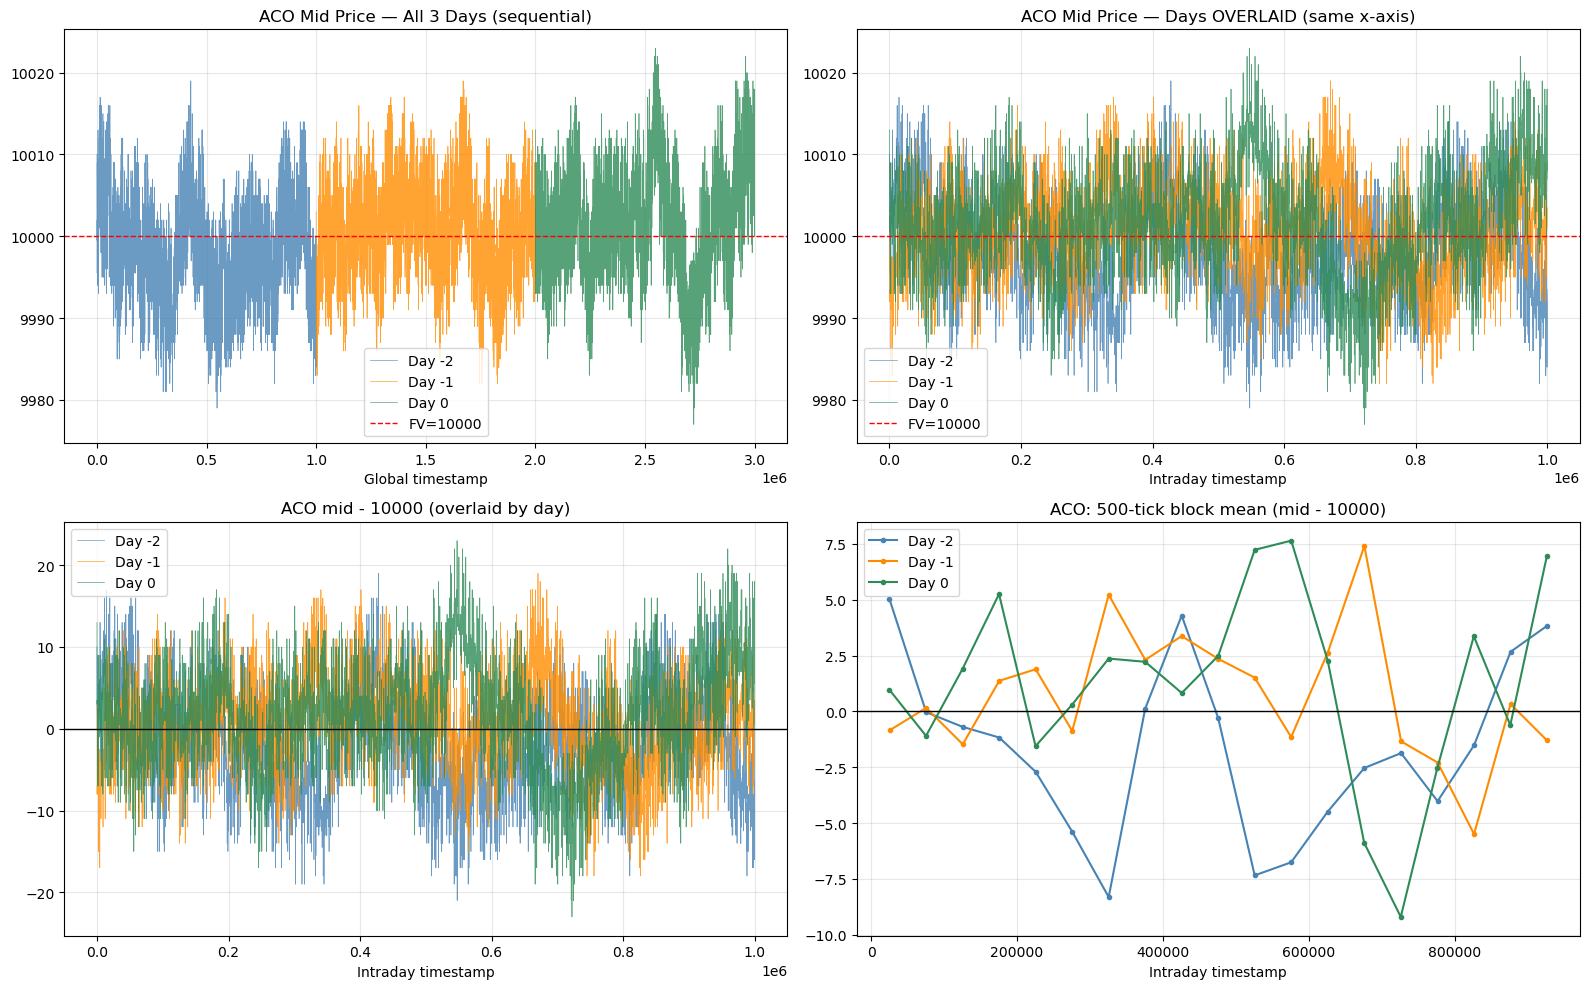

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: all 3 days on ONE timeline
ax = axes[0][0]
for d in DAYS:
    ds = aco[aco['day'] == d]
    ax.plot(ds['global_raw'], ds['mid_price'], lw=0.5, color=colors[d], alpha=0.8, label=f'Day {d}')
ax.axhline(10000, color='red', lw=1, ls='--', label='FV=10000')
ax.set_title('ACO Mid Price — All 3 Days (sequential)')
ax.set_xlabel('Global timestamp'); ax.legend(); ax.grid(alpha=0.3)

# Top-right: OVERLAY all 3 days on same intraday timestamp (0–999900)
ax = axes[0][1]
for d in DAYS:
    ds = aco[aco['day'] == d]
    ax.plot(ds['timestamp'], ds['mid_price'], lw=0.5, color=colors[d], alpha=0.8, label=f'Day {d}')
ax.axhline(10000, color='red', lw=1, ls='--', label='FV=10000')
ax.set_title('ACO Mid Price — Days OVERLAID (same x-axis)')
ax.set_xlabel('Intraday timestamp'); ax.legend(); ax.grid(alpha=0.3)

# Bottom-left: day-by-day residual (mid - 10000)
ax = axes[1][0]
for d in DAYS:
    ds = aco[aco['day'] == d]
    ax.plot(ds['timestamp'], ds['mid_price'] - 10000, lw=0.5, color=colors[d], alpha=0.8, label=f'Day {d}')
ax.axhline(0, color='black', lw=1)
ax.set_title('ACO mid - 10000 (overlaid by day)')
ax.set_xlabel('Intraday timestamp'); ax.legend(); ax.grid(alpha=0.3)

# Bottom-right: day means per 500-tick block
ax = axes[1][1]
for d in DAYS:
    ds = aco[aco['day'] == d].copy().reset_index(drop=True)
    block_size = 500
    n_blocks = len(ds) // block_size
    block_ts   = [ds.iloc[i*block_size + block_size//2]['timestamp'] for i in range(n_blocks)]
    block_mean = [ds.iloc[i*block_size:(i+1)*block_size]['mid_price'].mean() - 10000 for i in range(n_blocks)]
    ax.plot(block_ts, block_mean, lw=1.5, color=colors[d], label=f'Day {d}', marker='o', markersize=3)
ax.axhline(0, color='black', lw=1)
ax.set_title('ACO: 500-tick block mean (mid - 10000)')
ax.set_xlabel('Intraday timestamp'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

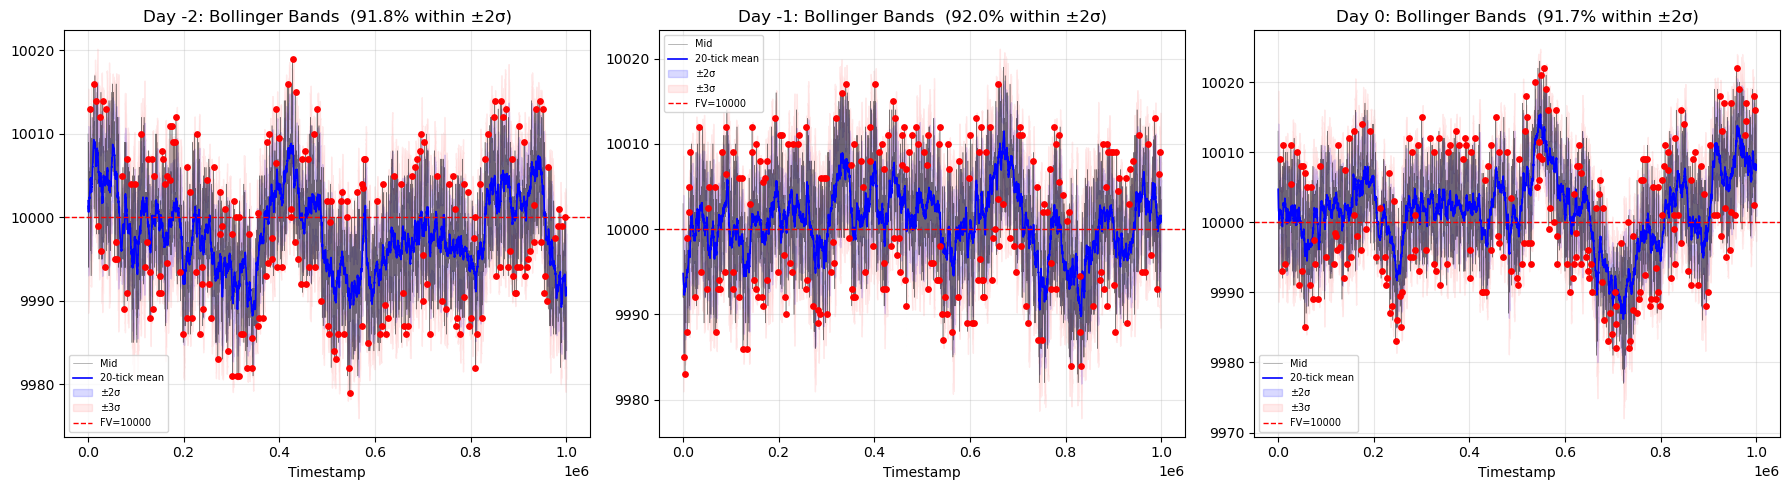

Day -2: roll_std mean=2.58, median=2.59
Day -1: roll_std mean=2.53, median=2.56
Day 0: roll_std mean=2.54, median=2.57


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
WINDOW = 20

for ax, d in zip(axes, DAYS):
    ds = aco[aco['day'] == d].copy().reset_index(drop=True)
    ds['roll_mean'] = ds['mid_price'].rolling(WINDOW, min_periods=5).mean()
    ds['roll_std']  = ds['mid_price'].rolling(WINDOW, min_periods=5).std()
    ds['bb_upper2'] = ds['roll_mean'] + 2 * ds['roll_std']
    ds['bb_lower2'] = ds['roll_mean'] - 2 * ds['roll_std']
    ds['bb_upper3'] = ds['roll_mean'] + 3 * ds['roll_std']
    ds['bb_lower3'] = ds['roll_mean'] - 3 * ds['roll_std']

    t = ds['timestamp']
    ax.plot(t, ds['mid_price'],   lw=0.4, color='black', alpha=0.5, label='Mid')
    ax.plot(t, ds['roll_mean'],   lw=1.2, color='blue',  label='20-tick mean')
    ax.fill_between(t, ds['bb_lower2'], ds['bb_upper2'], alpha=0.15, color='blue', label='±2σ')
    ax.fill_between(t, ds['bb_lower3'], ds['bb_upper3'], alpha=0.08, color='red',  label='±3σ')
    ax.axhline(10000, color='red', lw=1, ls='--', label='FV=10000')

    # Mark touches of outer band
    touch3 = ds[ds['mid_price'] > ds['bb_upper3']]
    ax.scatter(touch3['timestamp'], touch3['mid_price'], color='red', s=15, zorder=5)
    touch3l = ds[ds['mid_price'] < ds['bb_lower3']]
    ax.scatter(touch3l['timestamp'], touch3l['mid_price'], color='red', s=15, zorder=5)

    pct_in2 = ((ds['mid_price'] >= ds['bb_lower2']) & (ds['mid_price'] <= ds['bb_upper2'])).mean()
    ax.set_title(f'Day {d}: Bollinger Bands  ({pct_in2:.1%} within ±2σ)')
    ax.set_xlabel('Timestamp'); ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# What is the std of the 20-tick rolling std?
for d in DAYS:
    ds = aco[aco['day'] == d].copy()
    roll_std = ds['mid_price'].rolling(20, min_periods=5).std()
    print(f'Day {d}: roll_std mean={roll_std.mean():.2f}, median={roll_std.median():.2f}')